# Task 4.2 - Valutazione di Naive-Bayes su `training_clean.csv`

Nel Task 2.2 abbiamo applicato il classificatore di Naive-Bayes su `manuale.csv` prima manualmente e poi in python. Quella valutazione è però poco significativa, perchè fatta su un dataset di appena 14 campioni che non è pienamente rappresentativo dei dati contenuti in `training.csv`.

In questo notebook applichiamo Naive-Bayes ai 49.799 campioni di
`training_clean.csv` (il dataset ripulito ottenuto dal Task 3), che il modello non ha mai visto
e che hanno la proporzione reale delle classi (~99% classe 0, ~1% dropout).

Il lavoro si divide in cinque parti:
1. Applicare Naive-Bayes senza modificarlo e misurarne le prestazioni;
2. Spiegare i risultati ottenuti;
3. Valutare le prestazioni;
4. Provare a migliorare le prestazioni del classificatore;
4. Trarre le conclusioni in vista del Task 5.

## 1 - Applicazione del classificatore di Naive-Bayes sul dataset `training_clean.csv`
Riprendiamo il modello del Task 2.2 *senza modificarlo*: le probabilità restano
quelle stimate su `manuale.csv` (stimatore di Laplace e valori di *k* calcolati
sull'intero dataset). L'obiettivo non è ri-addestrare, ma misurare come si comporta su
dati nuovi il modello costruito sui 14 campioni.

Per efficienza, invece di ricontare le frequenze su `manuale.csv` a ogni riga (lento su
50.000 osservazioni), le calcoliamo **una volta sola** e le salviamo in una tabella di
probabilità: il risultato è identico al Task 2.2, solo più veloce.

### 1.1 - Carica dati e parametri

In [1]:
import pandas as pd

# dati su cui valutiamo: training_clean.csv (output del Task 3)
df = pd.read_csv("../data/training_clean.csv")

# sorgente del modello: le frequenze restano quelle di manuale.csv (Task 2.2)
man = pd.read_csv("../data/manuale.csv")

FEATS = ["FEATURE0", "FEATURE1", "FEATURE2", "FEATURE3"]
K = {"FEATURE0": 26, "FEATURE1": 16, "FEATURE2": 87, "FEATURE3": 164}
n1 = (man["LABEL"] == 1).sum()
n0 = (man["LABEL"] == 0).sum()
N = len(man)

print("training_clean:", df.shape)
print(df["LABEL"].value_counts().to_dict())

training_clean: (49799, 9)
{0: 49309, 1: 490}


### 1.2 - Tabelle di probabilità del modello, con Laplace

In [2]:
# prob[classe][feature][valore] = P(feature = valore | classe), stimata su manuale.csv
# E' la formula di Laplace del Task 2.2: (conteggio + 1) / (n_classe + k)
prob = {1: {}, 0: {}}
for f in FEATS:
    for classe, n in ((1, n1), (0, n0)):
        tabella = {}
        for v in man[f].unique():
            conteggio = ((man[f] == v) & (man["LABEL"] == classe)).sum()
            tabella[v] = (conteggio + 1) / (n + K[f])
        # valore mai visto in manuale.csv: conteggio = 0, quindi 1 / (n_classe + k)
        tabella["_mai_visto_"] = 1 / (n + K[f])
        prob[classe][f] = tabella

### 1.3 - Applica il classificatore a training_clean

In [3]:
def score(riga, classe):
    """Priori x prodotto delle P(feature | classe), lette dalle tabelle sopra."""
    risultato = (n1 if classe == 1 else n0) / N
    for f in FEATS:
        tabella = prob[classe][f]
        # se il valore non è tra quelli visti in manuale, uso il caso "_mai_visto_"
        risultato *= tabella.get(riga[f], tabella["_mai_visto_"])
    return risultato

def classifica(riga):
    return 1 if score(riga, 1) > score(riga, 0) else 0

df["PREDETTA"] = df.apply(classifica, axis=1)

# prima verifica: quante righe finiscono in ciascuna classe?
df["PREDETTA"].value_counts()

PREDETTA
1    48520
0     1279
Name: count, dtype: int64

## 2 - Considerazioni sui risultati ottenuti
Confrontiamo la distribuzione delle predizioni con quella reale, poi vediamo perché il modello si comporta così.

In [4]:
confronto = pd.DataFrame({
    "reale": df["LABEL"].value_counts(),
    "predetta": df["PREDETTA"].value_counts(),
})
confronto

,reale,predetta
0,49309,1279
1,490,48520


**Osservazione 1 — il modello predice troppi dropout.**
Il modello prevede "dropout" per 48.520 righe su 49.799, ma i dropout reali sono solo 490. La causa è che `manuale.csv` era bilanciato artificialmente (7 dropout + 7 non-dropout), mentre nei dati reali il dropout è raro (~1%). Il modello ha quindi imparato una proporzione di classi molto diversa da quella vera.

**Osservazione 2 — molti valori delle feature non erano mai comparsi in `manuale.csv`.**
Con soli 14 campioni, il modello ha "visto" solo una piccola parte dei valori possibili di ogni feature (es. 8 valori su 87 per FEATURE2). Controlliamo quante righe di `training_clean.csv` hanno almeno una feature con un valore mai incontrato in `manuale.csv`.

In [5]:
mai_visto = pd.Series(False, index=df.index)
for f in FEATS:
    valori_noti = set(man[f].unique())
    mai_visto |= ~df[f].isin(valori_noti)

print(f"Righe con almeno una feature mai vista in manuale.csv: "
      f"{mai_visto.sum()} su {len(df)} ({mai_visto.mean()*100:.1f}%)")

Righe con almeno una feature mai vista in manuale.csv: 37367 su 49799 (75.0%)


Il 75% delle righe ha almeno un valore mai visto: per queste feature il modello non usa una vera frequenza osservata, ma la probabilità "di riserva" dello stimatore di Laplace. Questo, insieme allo sbilanciamento delle classi, spiega le prestazioni che misuriamo nella prossima sezione.

## 3 - Valutazione delle prestazioni

### 3.1 - Confusion matrix
Ogni predizione cade in uno di quattro casi: TP e TN (predizioni corrette), FP (falso allarme), FN (dropout non riconosciuto).

In [6]:
TP = ((df["LABEL"] == 1) & (df["PREDETTA"] == 1)).sum()   # dropout riconosciuti
TN = ((df["LABEL"] == 0) & (df["PREDETTA"] == 0)).sum()   # "continua" riconosciuti
FP = ((df["LABEL"] == 0) & (df["PREDETTA"] == 1)).sum()   # falsi allarmi
FN = ((df["LABEL"] == 1) & (df["PREDETTA"] == 0)).sum()   # dropout mancati

pd.DataFrame([[TN, FP], [FN, TP]],
             index=["Reale 0", "Reale 1"],
             columns=["Predetta 0", "Predetta 1"])

,Predetta 0,Predetta 1
Reale 0,1273,48036
Reale 1,6,484


### 3.2 - Metriche
Usiamo le stesse quattro metriche del Task 4.1:

$$Accuracy = \frac{TP+TN}{TP+TN+FP+FN} \qquad Precision = \frac{TP}{TP+FP} \qquad Recall = \frac{TP}{TP+FN} \qquad F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [7]:
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.0353
Precision: 0.0100
Recall:    0.9878
F1-score:  0.0198


### 3.3 - Confronto con i risultati del Task 2.2

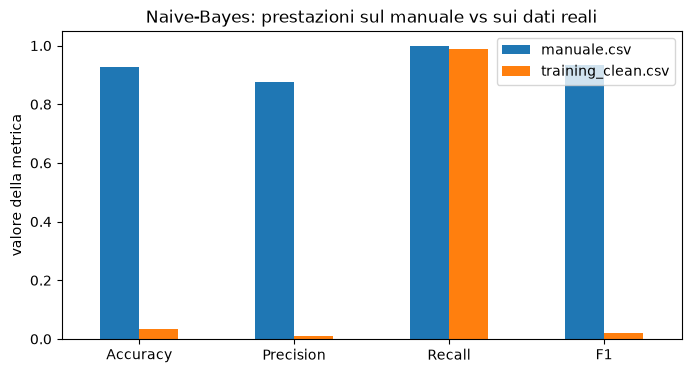

,manuale.csv,training_clean.csv
Accuracy,0.9286,0.0353
Precision,0.8750,0.0100
Recall,1.0000,0.9878
F1,0.9333,0.0198


In [8]:
import matplotlib.pyplot as plt

# le metriche ottenute nel Task 2.2 sui 14 campioni di manuale.csv
sul_manuale  = {"Accuracy": 0.9286, "Precision": 0.8750, "Recall": 1.0, "F1": 0.9333}
sul_training = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}

confronto_22 = pd.DataFrame({"manuale.csv": sul_manuale, "training_clean.csv": sul_training})

confronto_22.plot(kind="bar", figsize=(8, 4), rot=0,
                  title="Naive-Bayes: prestazioni sul manuale vs sui dati reali")
plt.ylabel("valore della metrica")
plt.show()

confronto_22.round(4)

Regge solo la recall (98.8%): il modello trova quasi tutti i dropout, ma solo perché dice "dropout" quasi sempre. Precision e accuracy crollano: **1 solo allarme vero ogni 100 lanciati**. È lo stesso pattern osservato per l'albero nel Task 4.1, e le cause sono le due viste nella Sezione 2.

## 4 - Ottimizzazione delle prestazioni

Proviamo due strade semplici, entrambe naturali per Naive-Bayes.

### 4.1 - Correggere le probabilità a priori
Il modello usa i priori del manuale ($\frac{7}{14}$ e $\frac{7}{14}$), ma sappiamo che le proporzioni reali sono ~1% / ~99%. Naive-Bayes permette di correggerle senza toccare il resto del modello: basta sostituire i priori nella formula dello score.

In [9]:
p1_reale = (df["LABEL"] == 1).mean()   # ~0.0098
p0_reale = 1 - p1_reale

def classifica_priori_reali(riga):
    s1 = p1_reale
    s0 = p0_reale
    for f in FEATS:
        s1 *= prob[1][f].get(riga[f], prob[1][f]["_mai_visto_"])
        s0 *= prob[0][f].get(riga[f], prob[0][f]["_mai_visto_"])
    return 1 if s1 > s0 else 0

df["PRED_PRIORI"] = df.apply(classifica_priori_reali, axis=1)
df["PRED_PRIORI"].value_counts()

PRED_PRIORI
0    49799
Name: count, dtype: int64

Il modello degenera nel "sempre 0": con un priore dell'1%, nessuna evidenza delle 4 feature è abbastanza forte da ribaltare la decisione. Accuracy 99% ma recall e F1 pari a zero — esattamente come il tentativo 5.1 del Task 4.1. La conclusione è la stessa.

### 4.2 - Scegliere una soglia sulla probabilità
La via di mezzo: teniamo i priori del manuale ma, invece di predire 1 quando $P(1 \mid E) > 50\%$, alziamo la soglia: così il modello segnala solo i casi in cui è più "convinto". Calcoliamo $P(1 \mid E)$ per ogni riga e proviamo alcune soglie.

In [10]:
def probabilita_dropout(riga):
    s1 = score(riga, 1)
    s0 = score(riga, 0)
    return s1 / (s1 + s0)   # normalizzazione, come nel Task 2.2

df["P1"] = df.apply(probabilita_dropout, axis=1)

for soglia in [0.5, 0.6, 0.7, 0.8, 0.9]:
    pred = (df["P1"] > soglia).astype(int)
    tp = ((df["LABEL"] == 1) & (pred == 1)).sum()
    fp = ((df["LABEL"] == 0) & (pred == 1)).sum()
    fn = ((df["LABEL"] == 1) & (pred == 0)).sum()
    prec = tp / (tp + fp) if tp + fp else 0
    rec  = tp / (tp + fn) if tp + fn else 0
    f1_s = 2 * prec * rec / (prec + rec) if prec + rec else 0
    print(f"soglia {soglia}:  precision={prec:.3f}  recall={rec:.3f}  F1={f1_s:.4f}")

soglia 0.5:  precision=0.010  recall=0.988  F1=0.0198
soglia 0.6:  precision=0.010  recall=0.965  F1=0.0198
soglia 0.7:  precision=0.016  recall=0.541  F1=0.0308
soglia 0.8:  precision=0.024  recall=0.488  F1=0.0450
soglia 0.9:  precision=0.000  recall=0.000  F1=0.0000


La soglia migliore è **0.8**: l'F1 sale da 0.020 a 0.045 (più che doppio) perché i falsi positivi scendono da ~48.000 a ~10.000. In cambio la recall scende dal 99% al 49%: il solito compromesso tra precision e recall. Oltre 0.8 il modello non segnala più nulla (F1 = 0), perché nessuna riga raggiunge $P(1 \mid E) > 0.9$.

In [11]:
# riepilogo delle tre varianti provate
pred_08 = (df["P1"] > 0.8).astype(int)
tp = ((df["LABEL"] == 1) & (pred_08 == 1)).sum()
fp = ((df["LABEL"] == 0) & (pred_08 == 1)).sum()
fn = ((df["LABEL"] == 1) & (pred_08 == 0)).sum()
tn = ((df["LABEL"] == 0) & (pred_08 == 0)).sum()
acc_08  = (tp + tn) / len(df)
prec_08 = tp / (tp + fp)
rec_08  = tp / (tp + fn)
f1_08   = 2 * prec_08 * rec_08 / (prec_08 + rec_08)

acc_zero = (df["LABEL"] == 0).mean()   # il "sempre 0" della sezione 4.1

riepilogo = pd.DataFrame({
    "NB Task 2.2":     [accuracy, precision, recall, f1],
    "NB priori reali": [acc_zero, 0, 0, 0],
    "NB soglia 0.8":   [acc_08, prec_08, rec_08, f1_08],
}, index=["Accuracy", "Precision", "Recall", "F1"])

riepilogo.round(4)

,NB Task 2.2,NB priori reali,NB soglia 0.8
Accuracy,0.0353,0.9902,0.7962
Precision,0.0100,0.0000,0.0236
Recall,0.9878,0.0000,0.4878
F1,0.0198,0.0000,0.0450


## 5 - Conclusioni

Tre conclusioni in vista del Task 5:

1. **Il modello del Task 2.2 non generalizza**: costruito su 14 campioni bilanciati, sui dati reali ottiene F1 = 0.020. Le cause sono lo sbilanciamento delle classi e il fatto che il 75% delle righe contiene valori mai visti nel manuale.
2. **Le ottimizzazioni semplici hanno un tetto basso**: la soglia a 0.8 porta l'F1 a 0.045 — lo stesso valore raggiunto dall'albero ottimizzato nel Task 4.1. Con così pochi dati di addestramento, nessuna delle due famiglie di modelli riesce a fare meglio.
